# TP Final — Minería y Modelizado de Datos
## IFTS N° 24 | 1° Cuatrimestre 2026
### Materia: Minería y Modelizado de Datos

**Caso de negocio:** Segmentación de clientes y análisis de canasta en una tienda de artículos del hogar  
**Algoritmos:** K-Means (segmentación de clientes) + Reglas de Asociación con APRIORI  
**Dataset:** `online_retail_hogar.csv` — datos sintéticos (tienda argentina, precios en ARS)  

---
> **Integrantes del grupo:** *(completar con los nombres)*  
> **Grupo:** 3 a 4 integrantes


---
## FASE 1 — Comprensión del negocio y definición del problema

### Contexto
Una tienda de artículos del hogar quiere mejorar su estrategia comercial usando sus datos históricos de ventas.  
El dueño necesita responder dos preguntas clave:

1. **¿Quiénes son mis clientes?** → Segmentarlos según comportamiento de compra para personalizar ofertas.
2. **¿Qué productos se compran juntos?** → Detectar combinaciones frecuentes para diseñar promociones cruzadas.

### Objetivos del proyecto
- Construir perfiles de clientes mediante **K-Means** usando variables de comportamiento de compra (días desde última compra, frecuencia y monto gastado).
- Descubrir **reglas de asociación** entre productos usando el algoritmo **APRIORI**.
- Traducir los hallazgos en **al menos 2 recomendaciones accionables** para el negocio.

### Metodología
Se sigue el proceso **CRISP-DM**: comprensión del negocio → preparación de datos → modelado → evaluación → conclusiones.


---
## FASE 2 — Preparación y exploración de los datos (EDA)

### 2.1 Importación de librerías


In [1]:
# Librerías estándar de análisis y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Reglas de asociación
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Configuración visual
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
print("✅ Librerías importadas correctamente")


✅ Librerías importadas correctamente


### 2.2 Carga del dataset


In [2]:
# Cargamos el dataset desde la carpeta TP_Final
df = pd.read_csv('online_retail_hogar.csv', parse_dates=['FechaFactura'])

print(f"Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nColumnas: {list(df.columns)}")
df.head(8)


Dimensiones del dataset: 9,363 filas × 9 columnas

Columnas: ['NroFactura', 'IDCliente', 'Descripcion', 'Categoria', 'Cantidad', 'PrecioUnitario', 'PrecioTotal', 'FechaFactura', 'Ciudad']


,NroFactura,IDCliente,Descripcion,Categoria,Cantidad,PrecioUnitario,PrecioTotal,FechaFactura,Ciudad
0,FAC02563,C0225,Planta Artificial,Decoracion,2,16600.0,33200.0,2023-06-19,Buenos Aires
1,FAC02563,C0225,Maceta Ceramica,Decoracion,2,12100.0,24200.0,2023-06-19,Buenos Aires
2,FAC02563,C0225,Perchero Entrada,Decoracion,3,33200.0,99600.0,2023-06-19,Buenos Aires
3,FAC02651,C0238,Bolsa Regalo Grande,Regaleria,2,3000.0,6000.0,2023-06-27,Buenos Aires
4,FAC02651,C0238,Mantel Navideno,Decoracion,3,22600.0,67800.0,2023-06-27,Buenos Aires
5,FAC02817,C0258,Salero Porcelana,Cocina,4,10600.0,42400.0,2023-07-29,Mar del Plata
6,FAC02817,C0258,Pimentero Porcelana,Cocina,1,10600.0,10600.0,2023-07-29,Mar del Plata
7,FAC02817,C0258,Salero Porcelana,Cocina,4,10600.0,42400.0,2023-07-29,Mar del Plata


### 2.3 Descripción de las variables

| Variable | Tipo | Descripción |
|---|---|---|
| `NroFactura` | string | Identificador único de la factura |
| `IDCliente` | string | Identificador único del cliente |
| `Descripcion` | string | Nombre del producto |
| `Categoria` | string | Categoría del producto |
| `Cantidad` | int | Unidades compradas |
| `PrecioUnitario` | float | Precio unitario (ARS) |
| `PrecioTotal` | float | Importe total (Cantidad × PrecioUnitario) en ARS |
| `FechaFactura` | date | Fecha de la transacción |
| `Ciudad` | string | Ciudad del cliente |


In [3]:
# Resumen estadístico
print("=== INFORMACIÓN GENERAL ===")
df.info()
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
df[['Cantidad','PrecioUnitario','PrecioTotal']].describe().round(2)


=== INFORMACIÓN GENERAL ===
<class 'pandas.DataFrame'>
RangeIndex: 9363 entries, 0 to 9362
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   NroFactura      9363 non-null   str           
 1   IDCliente       9363 non-null   str           
 2   Descripcion     9363 non-null   str           
 3   Categoria       9363 non-null   str           
 4   Cantidad        9363 non-null   int64         
 5   PrecioUnitario  9363 non-null   float64       
 6   PrecioTotal     9363 non-null   float64       
 7   FechaFactura    9363 non-null   datetime64[us]
 8   Ciudad          9363 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(1), str(5)
memory usage: 658.5 KB

=== ESTADÍSTICAS DESCRIPTIVAS ===


,Cantidad,PrecioUnitario,PrecioTotal
count,9363.00,9363.00,9363.00
mean,2.51,12960.02,32516.26
std,1.13,8903.89,28525.36
min,1.00,1200.00,1200.00
25%,2.00,6000.00,11300.00
50%,3.00,10600.00,24000.00
75%,4.00,18100.00,45200.00
max,4.00,37800.00,151200.00


In [4]:
# Valores nulos
print("Valores nulos por columna:")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "Sin valores nulos ✅")

# Registros duplicados
dupes = df.duplicated().sum()
print(f"\nRegistros duplicados: {dupes}")


Valores nulos por columna:
Sin valores nulos ✅

Registros duplicados: 65


In [5]:
# ============================================================
# Inspección y tratamiento de duplicados
# ============================================================

# Antes de eliminar, inspeccionamos si los duplicados se concentran
# en pocos clientes (lo cual podría indicar otro problema) o están
# repartidos, consistente con un error de carga aleatorio.
duplicados = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
print(f"Total de filas involucradas en duplicados: {duplicados.shape[0]}")
print(f"\nClientes distintos afectados: {duplicados['IDCliente'].nunique()}")
print("\nEjemplo de filas duplicadas:")
print(duplicados.head(10))

# ============================================================
# Eliminación de duplicados
# ============================================================
# Se eliminan los registros duplicados, ya que en un dataset transaccional
# una fila idéntica repetida (misma factura, cliente, producto, cantidad
# y precio) corresponde a un error de carga/registro, no a una compra
# real coincidente en todos sus campos.

filas_antes = df.shape[0]
df = df.drop_duplicates()
filas_despues = df.shape[0]

print(f"\nFilas antes de eliminar duplicados: {filas_antes:,}")
print(f"Filas eliminadas: {filas_antes - filas_despues}")
print(f"Filas después de eliminar duplicados: {filas_despues:,}")

Total de filas involucradas en duplicados: 130

Clientes distintos afectados: 60

Ejemplo de filas duplicadas:
     NroFactura IDCliente           Descripcion      Categoria  Cantidad  \
3261   FAC01009     C0002  Papel Tissue Colores      Regaleria         3   
3269   FAC01009     C0002  Papel Tissue Colores      Regaleria         3   
552    FAC01032     C0005      Cojin Decorativo     Decoracion         3   
554    FAC01032     C0005      Cojin Decorativo     Decoracion         3   
3649   FAC01102     C0019    Set Sal y Pimienta         Cocina         3   
3656   FAC01102     C0019    Set Sal y Pimienta         Cocina         3   
2247   FAC01231     C0033    Delantal de Cocina         Cocina         3   
2264   FAC01231     C0033    Delantal de Cocina         Cocina         3   
574    FAC01254     C0035    Aromatizador Hogar  Aromatizacion         1   
588    FAC01254     C0035    Aromatizador Hogar  Aromatizacion         1   

      PrecioUnitario  PrecioTotal FechaFactura      

**Conclusión:** Se detectaron 65 registros duplicados (filas idénticas en todos 
los campos), afectando a 60 clientes distintos de forma dispersa —sin 
concentración en ningún cliente particular—, lo cual es consistente con un 
error de carga/duplicación en el dataset original. Se eliminaron mediante 
`drop_duplicates()`, quedando el dataset en 9.298 registros.

### 2.4 Exploración visual del dataset


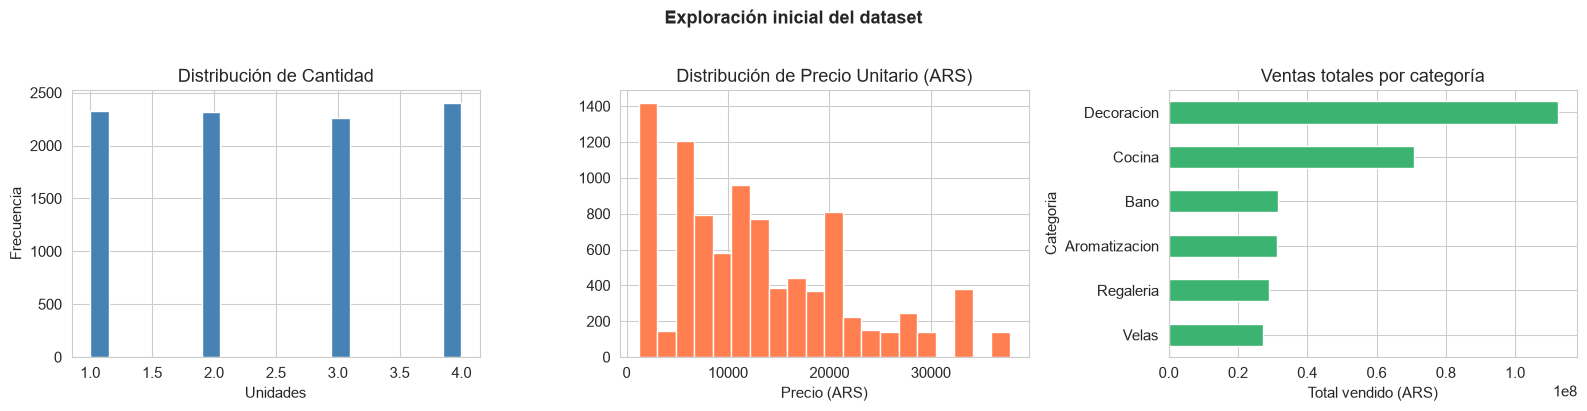

Figura guardada como 'grafico_eda.png'


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución de cantidad
axes[0].hist(df['Cantidad'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Cantidad')
axes[0].set_xlabel('Unidades')
axes[0].set_ylabel('Frecuencia')

# Distribución de precio unitario
axes[1].hist(df['PrecioUnitario'], bins=20, color='coral', edgecolor='white')
axes[1].set_title('Distribución de Precio Unitario (ARS)')
axes[1].set_xlabel('Precio (ARS)')

# Ventas por categoría
cat_ventas = df.groupby('Categoria')['PrecioTotal'].sum().sort_values(ascending=True)
cat_ventas.plot(kind='barh', ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Ventas totales por categoría')
axes[2].set_xlabel('Total vendido (ARS)')

plt.suptitle('Exploración inicial del dataset', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('grafico_eda.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figura guardada como 'grafico_eda.png'")


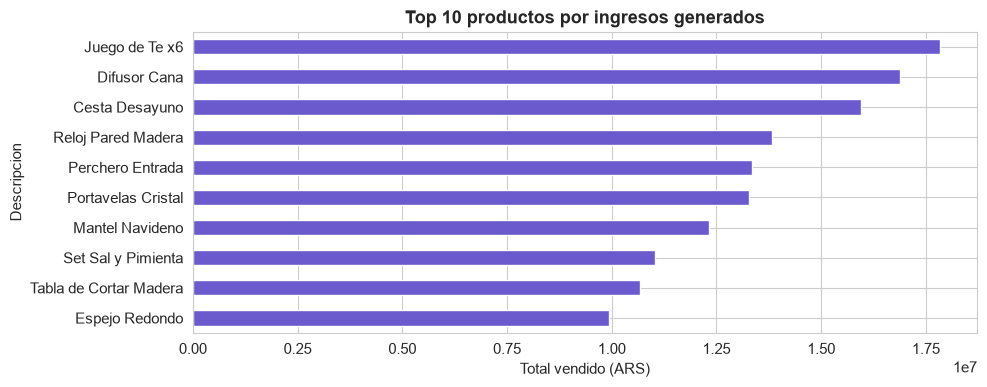

Descripcion
Juego de Te x6            17828400.0
Difusor Cana              16880000.0
Cesta Desayuno            15939200.0
Reloj Pared Madera        13834800.0
Perchero Entrada          13346400.0
Portavelas Cristal        13273600.0
Mantel Navideno           12317000.0
Set Sal y Pimienta        11034800.0
Tabla de Cortar Madera    10679000.0
Espejo Redondo             9935800.0


In [7]:
# Top 10 productos más vendidos (por ingresos)
top_productos = (
    df.groupby('Descripcion')['PrecioTotal']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 4))
top_productos.sort_values().plot(kind='barh', color='slateblue', edgecolor='white')
plt.title('Top 10 productos por ingresos generados', fontweight='bold')
plt.xlabel('Total vendido (ARS)')
plt.tight_layout()
plt.savefig('grafico_top_productos.png', dpi=120, bbox_inches='tight')
plt.show()

print(top_productos.to_string())


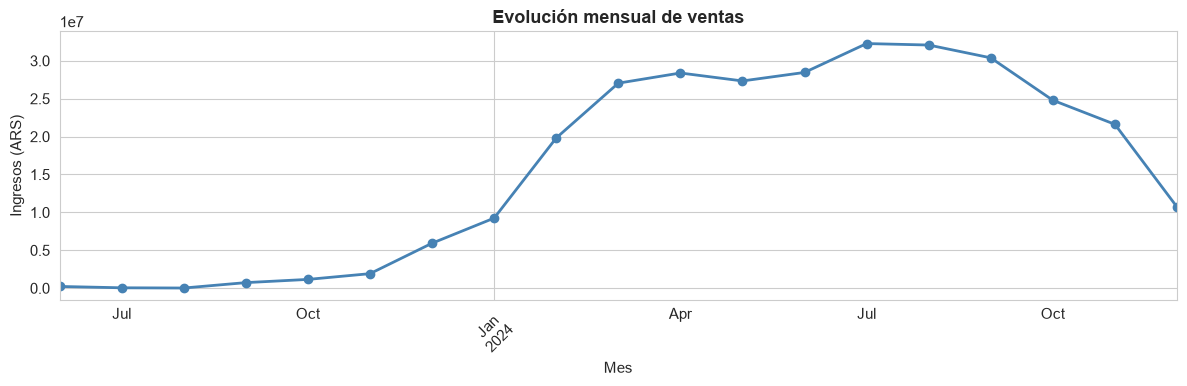

In [8]:
# Evolución temporal de ventas
df['Mes'] = df['FechaFactura'].dt.to_period('M')
ventas_mensuales = df.groupby('Mes')['PrecioTotal'].sum()

plt.figure(figsize=(12, 4))
ventas_mensuales.plot(kind='line', marker='o', color='steelblue', linewidth=2)
plt.title('Evolución mensual de ventas', fontweight='bold')
plt.ylabel('Ingresos (ARS)')
plt.xlabel('Mes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('grafico_ventas_mensuales.png', dpi=120, bbox_inches='tight')
plt.show()


---
## FASE 3 — Modelado

### PARTE A: Segmentación de clientes con K-Means

#### Variables de comportamiento de compra
Para aplicar K-Means necesitamos variables numéricas que describan a cada cliente. A partir de los datos transaccionales calculamos tres variables:
- **Días desde última compra:** ¿Hace cuántos días compró por última vez? (menor = cliente más activo)
- **Frecuencia:** ¿Cuántas facturas distintas tiene en el período? (mayor = cliente más fiel)
- **Monto total gastado:** ¿Cuánto dinero gastó en total? (mayor = cliente más valioso)

Luego aplicamos **K-Means** sobre estas variables estandarizadas para agrupar clientes con comportamiento similar.


#### 3.A.1 Cálculo de variables de comportamiento por cliente


In [9]:
# Fecha de referencia: día siguiente al último registro
fecha_ref = df['FechaFactura'].max() + pd.Timedelta(days=1)
print(f"Fecha de referencia: {fecha_ref.date()}")

# Calculamos 3 variables de comportamiento por cliente
rfm = df.groupby('IDCliente').agg(
    DiasDesdeUltimaCompra = ('FechaFactura', lambda x: (fecha_ref - x.max()).days),
    Frecuencia            = ('NroFactura',   'nunique'),
    MontoTotal            = ('PrecioTotal',  'sum')
).reset_index()

rfm['MontoTotal'] = rfm['MontoTotal'].round(2)

print(f"\nClientes únicos: {len(rfm)}")
print("\nResumen de variables de comportamiento:")
rfm[['DiasDesdeUltimaCompra','Frecuencia','MontoTotal']].describe().round(2)


Fecha de referencia: 2024-12-28

Clientes únicos: 400

Resumen de variables de comportamiento:


,DiasDesdeUltimaCompra,Frecuencia,MontoTotal
count,400.00,400.00,400.00
mean,121.48,6.98,755466.25
std,104.45,6.47,726591.00
min,1.00,1.00,11400.00
25%,38.75,2.00,226600.00
50%,89.00,5.00,509000.00
75%,177.25,9.25,1014425.00
max,550.00,30.00,3635400.00


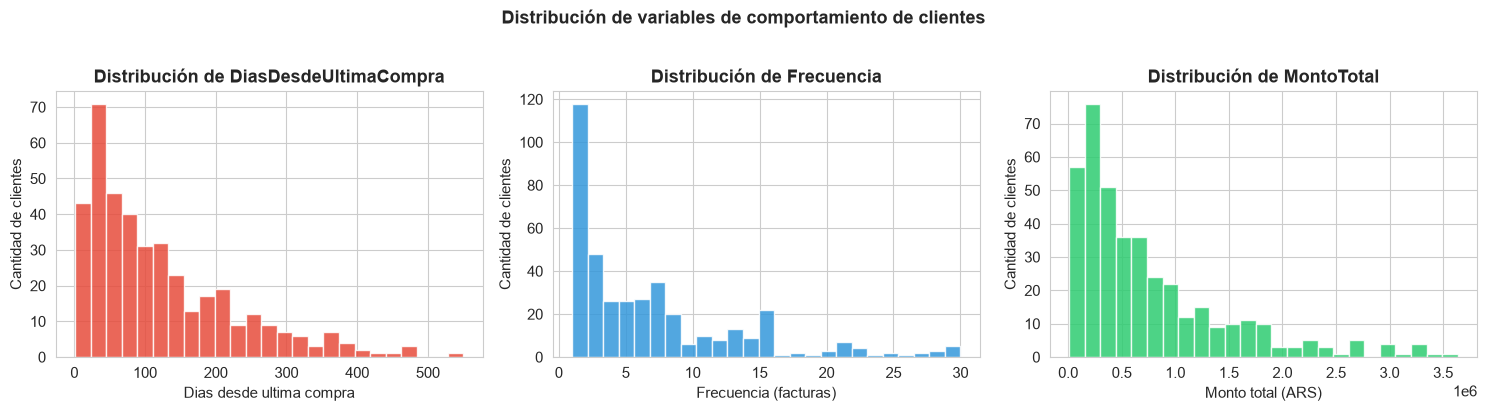

In [10]:
# Visualización de la distribución de variables de comportamiento
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colores = ['#e74c3c', '#3498db', '#2ecc71']
labels  = ['Dias desde ultima compra', 'Frecuencia (facturas)', 'Monto total (ARS)']

for ax, col, color, label in zip(axes, ['DiasDesdeUltimaCompra','Frecuencia','MontoTotal'], colores, labels):
    ax.hist(rfm[col], bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribución de {col}', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Cantidad de clientes')

plt.suptitle('Distribución de variables de comportamiento de clientes', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('grafico_comportamiento_distribucion.png', dpi=120, bbox_inches='tight')
plt.show()


#### 3.A.2 Preprocesamiento: estandarización de variables

K-Means usa distancias euclidianas, por lo que es **obligatorio estandarizar** las variables antes de aplicar el algoritmo (esto se menciona en el apunte, sección 'Escalado de Datos').  
Usamos `StandardScaler` → media=0, desvío estándar=1 para cada variable.


In [11]:
# Estandarización
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['DiasDesdeUltimaCompra','Frecuencia','MontoTotal']])
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Dias_scaled','Frec_scaled','Monto_scaled'])

print("Variables estandarizadas (primeras 5 filas):")
print(rfm_scaled_df.head().round(4).to_string())
print(f"\nMedia de cada variable (debe ser ~0): {rfm_scaled_df.mean().values.round(4)}")
print(f"Desvío de cada variable (debe ser ~1): {rfm_scaled_df.std().values.round(4)}")


Variables estandarizadas (primeras 5 filas):
   Dias_scaled  Frec_scaled  Monto_scaled
0       0.1680       0.0039       -0.2007
1      -0.8673       0.7771        1.0611
2       0.7240      -0.4601       -0.5003
3      -0.2250      -0.1508       -0.2038
4      -0.0237       0.0039        0.0669

Media de cada variable (debe ser ~0): [ 0.  0. -0.]
Desvío de cada variable (debe ser ~1): [1.0013 1.0013 1.0013]


#### 3.A.3 Selección del número óptimo de clusters (K)

Usamos dos métodos complementarios:
1. **Método del Codo (Elbow):** graficamos la inercia (suma de distancias cuadradas intra-cluster) en función de K. El "codo" indica el punto donde agregar más clusters ya no reduce significativamente la inercia.
2. **Silhouette Score:** mide qué tan bien separados están los clusters. Rango [-1, 1], valores más altos indican mejor definición.


In [12]:
# Hiperparámetros fijos para todos los experimentos
INIT       = 'k-means++'   # Inicialización inteligente para evitar mínimos locales
N_INIT     = 10            # Número de inicializaciones (se queda con la mejor)
MAX_ITER   = 300           # Máximo de iteraciones por ejecución
RANDOM_STATE = 42          # Semilla para reproducibilidad

inercias    = []
silhouettes = []
rango_k     = range(2, 11)

for k in rango_k:
    km = KMeans(n_clusters=k, init=INIT, n_init=N_INIT, max_iter=MAX_ITER, random_state=RANDOM_STATE)
    km.fit(rfm_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, km.labels_))
    print(f"  K={k:2d} | Inercia: {km.inertia_:8.1f} | Silhouette: {silhouette_score(rfm_scaled, km.labels_):.4f}")


  K= 2 | Inercia:    547.8 | Silhouette: 0.5255
  K= 3 | Inercia:    311.3 | Silhouette: 0.4770
  K= 4 | Inercia:    197.5 | Silhouette: 0.4874
  K= 5 | Inercia:    151.7 | Silhouette: 0.4260
  K= 6 | Inercia:    120.5 | Silhouette: 0.4099
  K= 7 | Inercia:    101.1 | Silhouette: 0.4054
  K= 8 | Inercia:     85.4 | Silhouette: 0.3859
  K= 9 | Inercia:     71.6 | Silhouette: 0.3960
  K=10 | Inercia:     62.8 | Silhouette: 0.3875


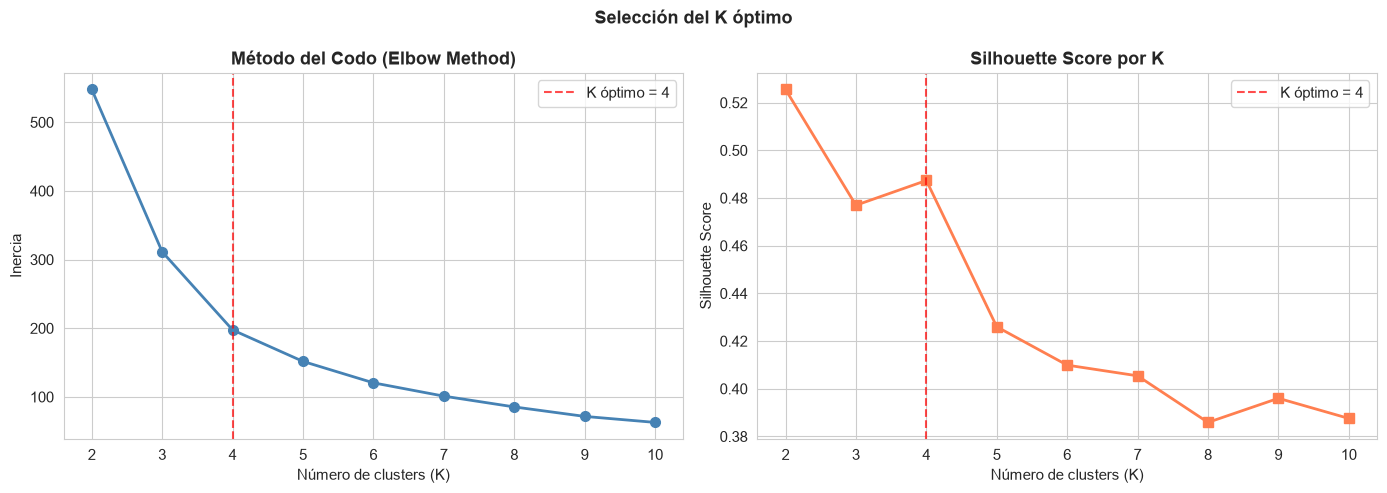


K optimo seleccionado (K>=3): K = 4
  Silhouette Score: 0.4874
  (K=2 tiene Silhouette 0.5255 pero produce solo 2 segmentos)


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico del Codo
ax1.plot(list(rango_k), inercias, marker='o', color='steelblue', linewidth=2, markersize=7)
ax1.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K óptimo = 4')
ax1.set_title('Método del Codo (Elbow Method)', fontweight='bold')
ax1.set_xlabel('Número de clusters (K)')
ax1.set_ylabel('Inercia')
ax1.legend()
ax1.set_xticks(list(rango_k))

# Silhouette Score
ax2.plot(list(rango_k), silhouettes, marker='s', color='coral', linewidth=2, markersize=7)
ax2.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K óptimo = 4')
ax2.set_title('Silhouette Score por K', fontweight='bold')
ax2.set_xlabel('Número de clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.legend()
ax2.set_xticks(list(rango_k))

plt.suptitle('Selección del K óptimo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_elbow_silhouette.png', dpi=120, bbox_inches='tight')
plt.show()

# K=2 suele tener el Silhouette mas alto pero produce solo 2 segmentos
# con poco valor de negocio. Elegimos el mejor K >= 3.
K_OPTIMO = silhouettes[1:].index(max(silhouettes[1:])) + 3
print(f"\nK optimo seleccionado (K>=3): K = {K_OPTIMO}")
print(f"  Silhouette Score: {silhouettes[K_OPTIMO - 2]:.4f}")
print(f"  (K=2 tiene Silhouette {max(silhouettes):.4f} pero produce solo 2 segmentos)")


#### 3.A.4 Entrenamiento del modelo final con K óptimo

**Justificación de hiperparámetros:**
- `n_clusters=4`: elegido por ser el K con mayor Silhouette Score entre K≥3, y por coincidir con el quiebre del codo. (K=2 obtiene el Silhouette global máximo pero con solo 2 segmentos tiene escaso valor de negocio.)
- `init='k-means++'`: inicialización basada en probabilidades que reduce el riesgo de converger a mínimos locales respecto a la inicialización aleatoria.
- `n_init=10`: ejecuta el algoritmo 10 veces con distintas semillas y conserva la mejor solución (menor inercia).
- `max_iter=300`: cantidad máxima de iteraciones antes de forzar convergencia.
- `random_state=42`: garantiza reproducibilidad del resultado.


In [14]:
# Modelo final
K_FINAL = 4

km_final = KMeans(
    n_clusters   = K_FINAL,
    init         = 'k-means++',
    n_init       = 10,
    max_iter     = 300,
    random_state = 42
)
km_final.fit(rfm_scaled)

# Asignamos el cluster a la tabla de clientes
rfm['Cluster'] = km_final.labels_

sil_final = silhouette_score(rfm_scaled, km_final.labels_)
print(f"✅ Modelo entrenado con K={K_FINAL}")
print(f"   Inercia final:      {km_final.inertia_:.2f}")
print(f"   Silhouette Score:   {sil_final:.4f}")
print(f"   Iteraciones hasta convergencia: {km_final.n_iter_}")


✅ Modelo entrenado con K=4
   Inercia final:      197.49
   Silhouette Score:   0.4874
   Iteraciones hasta convergencia: 7


#### 3.A.5 Perfilado e interpretación de los clusters


In [15]:
# Estadísticas descriptivas por cluster (en escala original)
perfil = rfm.groupby('Cluster')[['DiasDesdeUltimaCompra','Frecuencia','MontoTotal']].agg(['mean','median']).round(2)
print("=== PERFIL DE CLUSTERS (valores originales) ===")
print(perfil.to_string())

# Tamaño de cada cluster
print("\n=== TAMAÑO DE CADA CLUSTER ===")
tamanio = rfm['Cluster'].value_counts().sort_index()
for c, n in tamanio.items():
    print(f"  Cluster {c}: {n} clientes ({n/len(rfm)*100:.1f}%)")


=== PERFIL DE CLUSTERS (valores originales) ===
        DiasDesdeUltimaCompra        Frecuencia         MontoTotal           
                         mean median       mean median        mean     median
Cluster                                                                      
0                       93.87   95.0       4.50    4.0   481555.28   467300.0
1                      280.20  262.0       1.87    2.0   205989.25   181200.0
2                       21.32   23.0      24.18   23.5  2693342.86  2679650.0
3                       40.67   37.5      13.04   13.0  1397330.00  1359850.0

=== TAMAÑO DE CADA CLUSTER ===
  Cluster 0: 199 clientes (49.8%)
  Cluster 1: 93 clientes (23.2%)
  Cluster 2: 28 clientes (7.0%)
  Cluster 3: 80 clientes (20.0%)


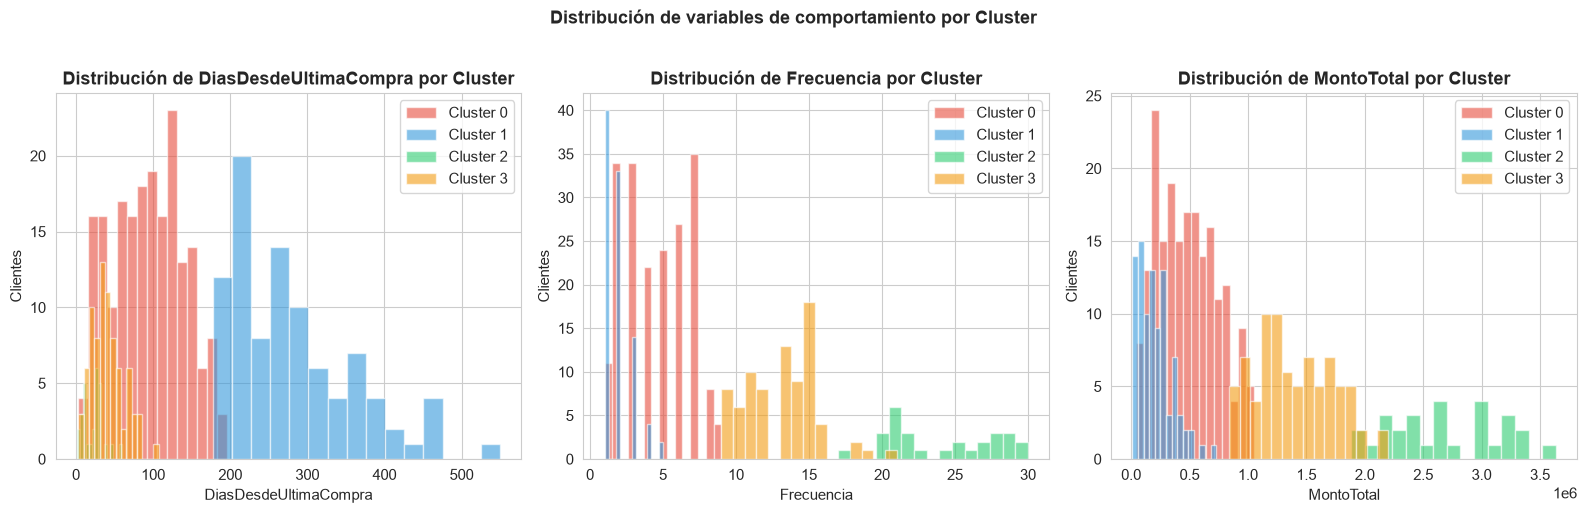

In [16]:
# Visualización: distribución de variables por cluster
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = ['#e74c3c','#3498db','#2ecc71','#f39c12']

for ax, var in zip(axes, ['DiasDesdeUltimaCompra','Frecuencia','MontoTotal']):
    for cluster_id in sorted(rfm['Cluster'].unique()):
        datos = rfm[rfm['Cluster'] == cluster_id][var]
        ax.hist(datos, bins=15, alpha=0.6, label=f'Cluster {cluster_id}',
                color=palette[cluster_id], edgecolor='white')
    ax.set_title(f'Distribución de {var} por Cluster', fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Clientes')
    ax.legend()

plt.suptitle('Distribución de variables de comportamiento por Cluster', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('grafico_comportamiento_clusters.png', dpi=120, bbox_inches='tight')
plt.show()


In [17]:
# Etiquetas interpretativas para cada cluster
# Basadas en los valores medios de R, F, M
medias = rfm.groupby('Cluster')[['DiasDesdeUltimaCompra','Frecuencia','MontoTotal']].mean()

# Ordenamos por Monetary descendente para asignar etiquetas
ranking_monetary = medias['MontoTotal'].rank(ascending=False)
ranking_recency  = medias['DiasDesdeUltimaCompra'].rank(ascending=True)   # menor recency = más reciente = mejor

# Asignamos etiquetas manualmente basadas en el perfil
etiquetas = {}
for cluster in medias.index:
    r = medias.loc[cluster, 'DiasDesdeUltimaCompra']
    f = medias.loc[cluster, 'Frecuencia']
    m = medias.loc[cluster, 'MontoTotal']
    
    if f >= medias['Frecuencia'].quantile(0.75) and m >= medias['MontoTotal'].quantile(0.75):
        etiquetas[cluster] = 'Clientes VIP'
    elif r >= medias['DiasDesdeUltimaCompra'].quantile(0.75):
        etiquetas[cluster] = 'Clientes en Riesgo / Dormidos'
    elif f >= medias['Frecuencia'].median():
        etiquetas[cluster] = 'Clientes Activos Frecuentes'
    else:
        etiquetas[cluster] = 'Clientes Ocasionales'

rfm['Perfil'] = rfm['Cluster'].map(etiquetas)

print("=== PERFILES ASIGNADOS ===")
for c, label in etiquetas.items():
    n = (rfm['Cluster'] == c).sum()
    m_mean = medias.loc[c, 'MontoTotal']
    f_mean = medias.loc[c, 'Frecuencia']
    r_mean = medias.loc[c, 'DiasDesdeUltimaCompra']
    print(f"  Cluster {c} → {label}")
    print(f"             Dias={r_mean:.0f}d | Frec={f_mean:.1f} | Monto=${m_mean:,.0f} ARS | n={n}")
    print()


=== PERFILES ASIGNADOS ===
  Cluster 0 → Clientes Ocasionales
             Dias=94d | Frec=4.5 | Monto=$481,555 ARS | n=199

  Cluster 1 → Clientes en Riesgo / Dormidos
             Dias=280d | Frec=1.9 | Monto=$205,989 ARS | n=93

  Cluster 2 → Clientes VIP
             Dias=21d | Frec=24.2 | Monto=$2,693,343 ARS | n=28

  Cluster 3 → Clientes Activos Frecuentes
             Dias=41d | Frec=13.0 | Monto=$1,397,330 ARS | n=80



Varianza explicada por PC1: 80.2%
Varianza explicada por PC2: 19.0%
Varianza total explicada:   99.1%


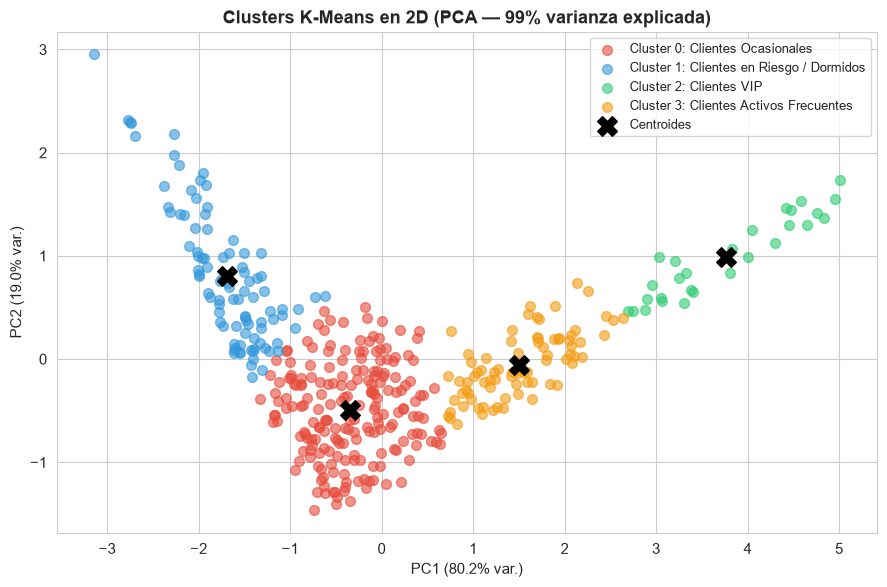

In [18]:
# Visualización 2D con PCA para ver la separación de clusters
pca = PCA(n_components=2, random_state=42)
rfm_2d = pca.fit_transform(rfm_scaled)

varianza_exp = pca.explained_variance_ratio_
print(f"Varianza explicada por PC1: {varianza_exp[0]*100:.1f}%")
print(f"Varianza explicada por PC2: {varianza_exp[1]*100:.1f}%")
print(f"Varianza total explicada:   {sum(varianza_exp)*100:.1f}%")

plt.figure(figsize=(9, 6))
for cluster_id in sorted(rfm['Cluster'].unique()):
    mask = rfm['Cluster'] == cluster_id
    plt.scatter(rfm_2d[mask, 0], rfm_2d[mask, 1],
                label=f"Cluster {cluster_id}: {etiquetas[cluster_id]}",
                color=palette[cluster_id], alpha=0.6, s=50)

# Centroides en espacio PCA
centroides_2d = pca.transform(km_final.cluster_centers_)
plt.scatter(centroides_2d[:, 0], centroides_2d[:, 1],
            marker='X', s=200, c='black', zorder=5, label='Centroides')

plt.title(f'Clusters K-Means en 2D (PCA — {sum(varianza_exp)*100:.0f}% varianza explicada)', fontweight='bold')
plt.xlabel(f'PC1 ({varianza_exp[0]*100:.1f}% var.)')
plt.ylabel(f'PC2 ({varianza_exp[1]*100:.1f}% var.)')
plt.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig('grafico_pca_clusters.png', dpi=120, bbox_inches='tight')
plt.show()


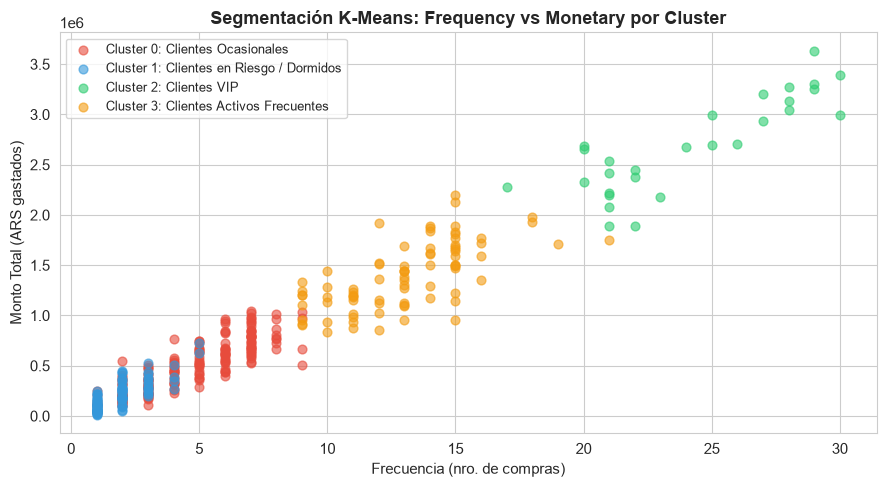

In [19]:
# Scatter — Frequency vs Monetary coloreado por cluster
plt.figure(figsize=(9, 5))
for cluster_id in sorted(rfm['Cluster'].unique()):
    mask = rfm['Cluster'] == cluster_id
    plt.scatter(rfm.loc[mask, 'Frecuencia'], rfm.loc[mask, 'MontoTotal'],
                label=f"Cluster {cluster_id}: {etiquetas[cluster_id]}",
                color=palette[cluster_id], alpha=0.6, s=40)

plt.title('Segmentación K-Means: Frequency vs Monetary por Cluster', fontweight='bold')
plt.xlabel('Frecuencia (nro. de compras)')
plt.ylabel('Monto Total (ARS gastados)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('grafico_scatter_clientes.png', dpi=120, bbox_inches='tight')
plt.show()


---
### PARTE B: Reglas de Asociación con APRIORI (market basket analysis)

#### ¿Por qué APRIORI?
El análisis de canasta (market basket) permite descubrir qué productos tienden a comprarse juntos en la misma transacción.  
El algoritmo APRIORI trabaja en dos fases:
1. **Encuentra itemsets frecuentes:** combinaciones de productos que superan un umbral de soporte (`min_support`).
2. **Genera reglas de asociación:** del tipo *"Si el cliente compra A, es probable que también compre B"*, evaluadas por Confianza y Lift.

#### Métricas clave
- **Soporte:** `P(A ∩ B)` — proporción de transacciones que contienen el itemset.
- **Confianza:** `P(B|A)` — dado que se compró A, probabilidad de que también se compre B.
- **Lift:** `Confianza / P(B)` — cuánto más probable es la compra conjunta respecto al azar. Lift > 1 indica asociación positiva.


#### 3.B.1 Preparación de la canasta de compras


In [20]:
# Crear la matriz binaria transacción × producto
# Una fila por factura, una columna por producto, 1 si fue comprado
basket = (
    df.groupby(['NroFactura', 'Descripcion'])['Cantidad']
    .sum()
    .unstack(fill_value=0)
    .astype(bool)   # True/False
)

print(f"Dimensiones de la matriz canasta: {basket.shape}")
print(f"  → {basket.shape[0]} transacciones")
print(f"  → {basket.shape[1]} productos únicos")
print(f"\nDensidad de la matriz: {basket.values.sum() / basket.size * 100:.2f}% de celdas son True")
basket.head(4)


Dimensiones de la matriz canasta: (2790, 40)
  → 2790 transacciones
  → 40 productos únicos

Densidad de la matriz: 8.16% de celdas son True


Descripcion,Album de Fotos,Aromatizador Hogar,Bolsa Regalo Grande,Bolsa Regalo Pequeña,Cesta Desayuno,Cojin Decorativo,Cuadro Motivacional,Delantal de Cocina,Difusor Cana,Dispensador Jabon,...,Set Sal y Pimienta,Set Velas x3,Tabla de Cortar Madera,Tarjeta Saludo,Taza Ceramica Blanca,Taza Ceramica Negra,Toallero Bambu,Vaso Bambu,Vela Aromatica Lavanda,Vela Aromatica Vainilla
NroFactura,,,,,,,,,,,,,,,,,,,,,
FAC01000,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
FAC01001,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
FAC01002,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
FAC01003,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


#### 3.B.2 Búsqueda de itemsets frecuentes

**Justificación de hiperparámetros:**
- `min_support=0.02`: itemsets que aparezcan en al menos el 2% de las transacciones. Un umbral demasiado alto no encuentra patrones; uno demasiado bajo genera ruido.
- `max_len=4`: limitamos a 4 ítems por itemset para mantener reglas interpretables.
- `use_colnames=True`: mostramos nombres de productos en lugar de índices.


In [21]:
# Parámetros del algoritmo APRIORI
MIN_SUPPORT = 0.02
MAX_LEN     = 4

# Fase 1: itemsets frecuentes
itemsets_frecuentes = apriori(
    basket,
    min_support  = MIN_SUPPORT,
    max_len      = MAX_LEN,
    use_colnames = True
)

itemsets_frecuentes['longitud'] = itemsets_frecuentes['itemsets'].apply(len)
itemsets_frecuentes = itemsets_frecuentes.sort_values('support', ascending=False).reset_index(drop=True)

print(f"✅ Itemsets frecuentes encontrados: {len(itemsets_frecuentes)}")
print(f"\nDistribución por longitud:")
print(itemsets_frecuentes['longitud'].value_counts().sort_index().to_string())
print("\nTop 15 itemsets por soporte:")
print(itemsets_frecuentes.head(15).to_string())


✅ Itemsets frecuentes encontrados: 67

Distribución por longitud:
longitud
1    40
2    23
3     4

Top 15 itemsets por soporte:
     support                              itemsets  longitud
0   0.133692       frozenset({Portavelas Cristal})         1
1   0.121864        frozenset({Jabonera Ceramica})         1
2   0.117204      frozenset({Bolsa Regalo Grande})         1
3   0.113978          frozenset({Lazo Decorativo})         1
4   0.112903     frozenset({Taza Ceramica Blanca})         1
5   0.112186   frozenset({Vela Aromatica Lavanda})         1
6   0.111111  frozenset({Vela Aromatica Vainilla})         1
7   0.110036             frozenset({Difusor Cana})         1
8   0.109677             frozenset({Esencia Rosa})         1
9   0.107527     frozenset({Papel Tissue Colores})         1
10  0.096057      frozenset({Pimentero Porcelana})         1
11  0.089606           frozenset({Esencia Jazmin})         1
12  0.086022        frozenset({Dispensador Jabon})         1
13  0.085305     

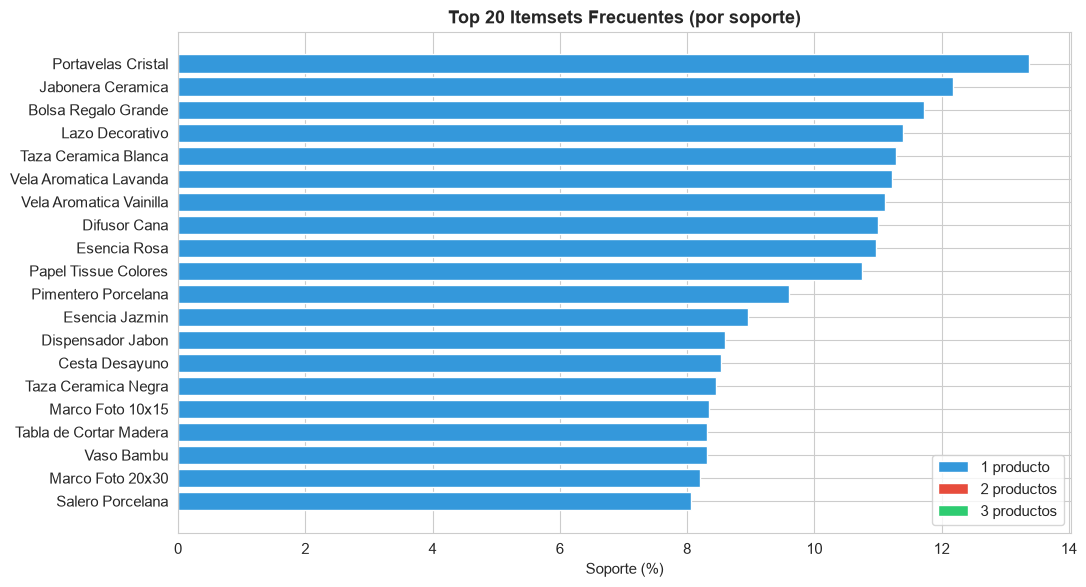

In [22]:
# Gráfico: soporte de los top 20 itemsets
top_items = itemsets_frecuentes.head(20).copy()
top_items['itemset_str'] = top_items['itemsets'].apply(lambda x: ', '.join(sorted(list(x))))

plt.figure(figsize=(11, 6))
colors = ['#3498db' if l==1 else '#e74c3c' if l==2 else '#2ecc71' for l in top_items['longitud']]
bars = plt.barh(top_items['itemset_str'], top_items['support']*100, color=colors, edgecolor='white')
plt.xlabel('Soporte (%)')
plt.title('Top 20 Itemsets Frecuentes (por soporte)', fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='1 producto'),
    Patch(facecolor='#e74c3c', label='2 productos'),
    Patch(facecolor='#2ecc71', label='3 productos')
]
plt.legend(handles=legend_elements, loc='lower right')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('grafico_itemsets.png', dpi=120, bbox_inches='tight')
plt.show()


#### 3.B.3 Generación de reglas de asociación

**Justificación de hiperparámetros:**
- `metric='lift'`: priorizamos reglas con asociación real (no coincidencias triviales).
- `min_threshold=1.2`: sólo reglas con Lift > 1.2, es decir donde la compra conjunta es al menos 20% más probable que por azar.


In [23]:
# Fase 2: generación de reglas
reglas = association_rules(
    itemsets_frecuentes,
    metric        = 'lift',
    min_threshold = 1.2
)

# Ordenar por lift descendente
reglas = reglas.sort_values('lift', ascending=False).reset_index(drop=True)

# Columnas a mostrar
cols_show = ['antecedents','consequents','support','confidence','lift','conviction']
print(f"✅ Reglas generadas: {len(reglas)}")
print("\nTop 20 reglas por Lift:")
print(reglas[cols_show].head(20).to_string())


✅ Reglas generadas: 70

Top 20 reglas por Lift:
                                                     antecedents                                                   consequents   support  confidence       lift  conviction
0                                    frozenset({Tarjeta Saludo})       frozenset({Bolsa Regalo Pequeña, Papel Tissue Colores})  0.028674    0.357143  11.862245    1.508722
1        frozenset({Bolsa Regalo Pequeña, Papel Tissue Colores})                                   frozenset({Tarjeta Saludo})  0.028674    0.952381  11.862245   19.313978
2              frozenset({Tarjeta Saludo, Papel Tissue Colores})                             frozenset({Bolsa Regalo Pequeña})  0.028674    0.851064  10.647839    6.177624
3                              frozenset({Bolsa Regalo Pequeña})             frozenset({Tarjeta Saludo, Papel Tissue Colores})  0.028674    0.358744  10.647839    1.506900
4               frozenset({Cesta Desayuno, Bolsa Regalo Grande})                            

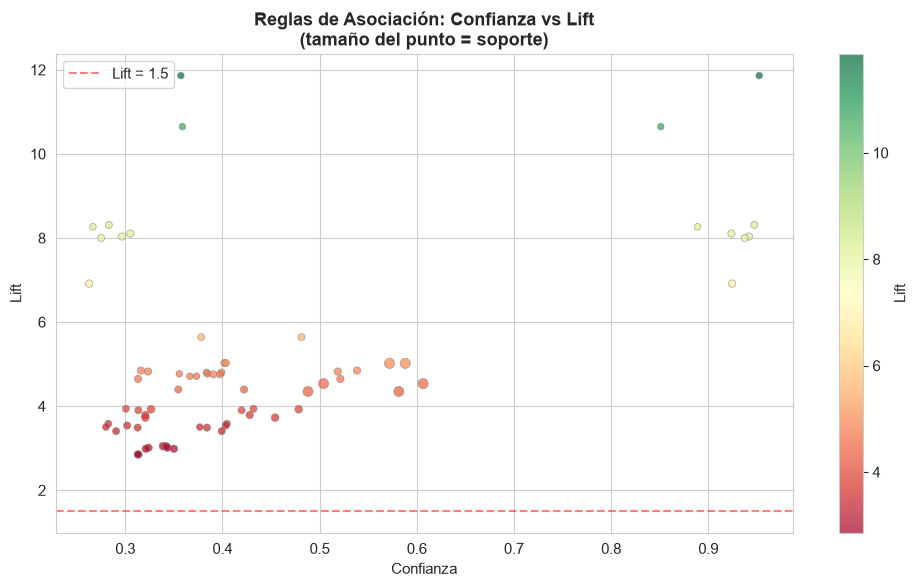

In [24]:
# Scatter: Confianza vs Lift (tamaño = soporte)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    reglas['confidence'],
    reglas['lift'],
    s=reglas['support'] * 800,
    c=reglas['lift'],
    cmap='RdYlGn',
    alpha=0.7,
    edgecolors='grey',
    linewidth=0.5
)
plt.colorbar(scatter, label='Lift')
plt.axhline(y=1.5, color='red', linestyle='--', alpha=0.5, label='Lift = 1.5')
plt.title('Reglas de Asociación: Confianza vs Lift\n(tamaño del punto = soporte)', fontweight='bold')
plt.xlabel('Confianza')
plt.ylabel('Lift')
plt.legend()
plt.tight_layout()
plt.savefig('grafico_reglas_scatter.png', dpi=120, bbox_inches='tight')
plt.show()


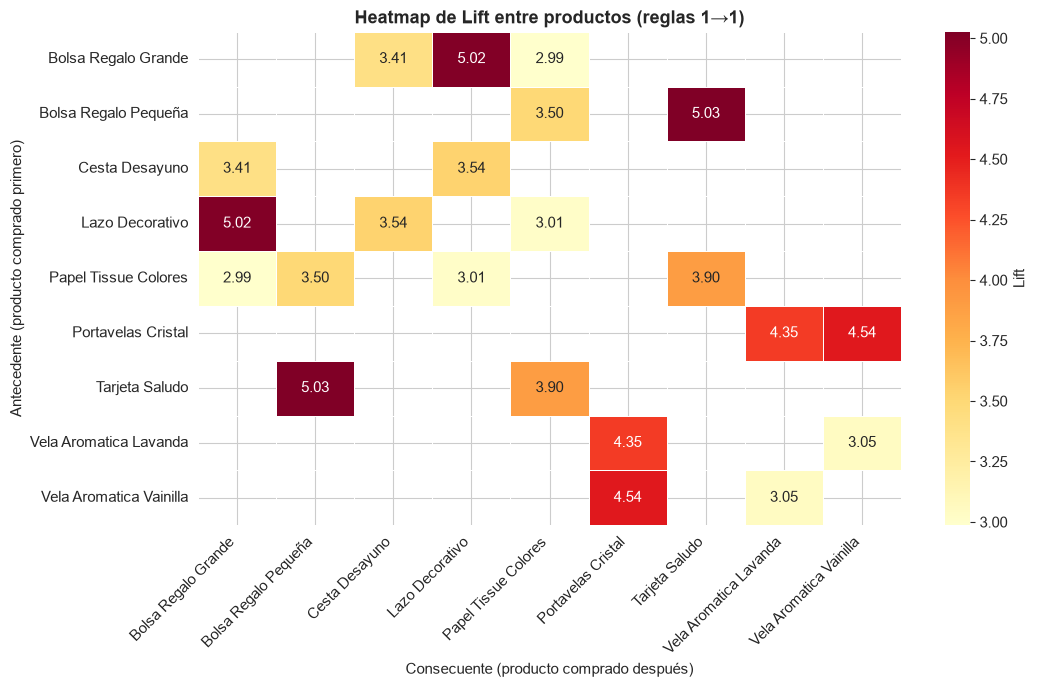

In [25]:
# Heatmap: matriz de lift entre productos más frecuentes
# Filtramos reglas con antecedente y consecuente de 1 solo producto
reglas_simples = reglas[
    (reglas['antecedents'].apply(len) == 1) &
    (reglas['consequents'].apply(len) == 1)
].copy()

reglas_simples['antecedente'] = reglas_simples['antecedents'].apply(lambda x: list(x)[0])
reglas_simples['consecuente'] = reglas_simples['consequents'].apply(lambda x: list(x)[0])

# Tomar los 12 productos que más aparecen en reglas
productos_en_reglas = pd.concat([
    reglas_simples['antecedente'],
    reglas_simples['consecuente']
]).value_counts().head(12).index.tolist()

pivot = reglas_simples[
    reglas_simples['antecedente'].isin(productos_en_reglas) &
    reglas_simples['consecuente'].isin(productos_en_reglas)
].pivot_table(index='antecedente', columns='consecuente', values='lift', aggfunc='max')

if len(pivot) >= 3:
    plt.figure(figsize=(11, 7))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5,
                cbar_kws={'label': 'Lift'})
    plt.title('Heatmap de Lift entre productos (reglas 1→1)', fontweight='bold')
    plt.xlabel('Consecuente (producto comprado después)')
    plt.ylabel('Antecedente (producto comprado primero)')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('grafico_heatmap_lift.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print("No hay suficientes reglas simples para el heatmap con los filtros actuales.")


---
## FASE 4 — Resultados, interpretación y recomendaciones de negocio

### 4.1 Resumen de resultados del clustering K-Means


In [26]:
# Tabla resumen de segmentos
resumen_clusters = rfm.groupby(['Cluster','Perfil']).agg(
    Clientes  = ('IDCliente', 'count'),
    R_media   = ('DiasDesdeUltimaCompra','mean'),
    F_media   = ('Frecuencia','mean'),
    M_media   = ('MontoTotal','mean'),
    M_total   = ('MontoTotal','sum')
).round(1).reset_index()

resumen_clusters['% Clientes'] = (resumen_clusters['Clientes'] / resumen_clusters['Clientes'].sum() * 100).round(1)
resumen_clusters['% Ingresos'] = (resumen_clusters['M_total'] / resumen_clusters['M_total'].sum() * 100).round(1)

print("=== RESUMEN FINAL DE SEGMENTACIÓN ===\n")
for _, row in resumen_clusters.iterrows():
    print(f"Cluster {int(row['Cluster'])} — {row['Perfil']}")
    print(f"  Clientes: {int(row['Clientes'])} ({row['% Clientes']}%) | "
          f"Recencia media: {row['R_media']:.0f}d | "
          f"Freq. media: {row['F_media']:.1f} | "
          f"Ticket medio: ${row['M_media']:.0f}")
    print(f"  Ingresos del segmento: ${row['M_total']:,.0f} ({row['% Ingresos']}% del total)\n")

print(f"Silhouette Score final: {sil_final:.4f}")
print(f"  → {'Buena' if sil_final >= 0.5 else 'Aceptable'} separación entre clusters")


=== RESUMEN FINAL DE SEGMENTACIÓN ===

Cluster 0 — Clientes Ocasionales
  Clientes: 199 (49.8%) | Recencia media: 94d | Freq. media: 4.5 | Ticket medio: $481555
  Ingresos del segmento: $95,829,500 (31.7% del total)

Cluster 1 — Clientes en Riesgo / Dormidos
  Clientes: 93 (23.2%) | Recencia media: 280d | Freq. media: 1.9 | Ticket medio: $205989
  Ingresos del segmento: $19,157,000 (6.3% del total)

Cluster 2 — Clientes VIP
  Clientes: 28 (7.0%) | Recencia media: 21d | Freq. media: 24.2 | Ticket medio: $2693343
  Ingresos del segmento: $75,413,600 (25.0% del total)

Cluster 3 — Clientes Activos Frecuentes
  Clientes: 80 (20.0%) | Recencia media: 41d | Freq. media: 13.0 | Ticket medio: $1397330
  Ingresos del segmento: $111,786,400 (37.0% del total)

Silhouette Score final: 0.4874
  → Aceptable separación entre clusters


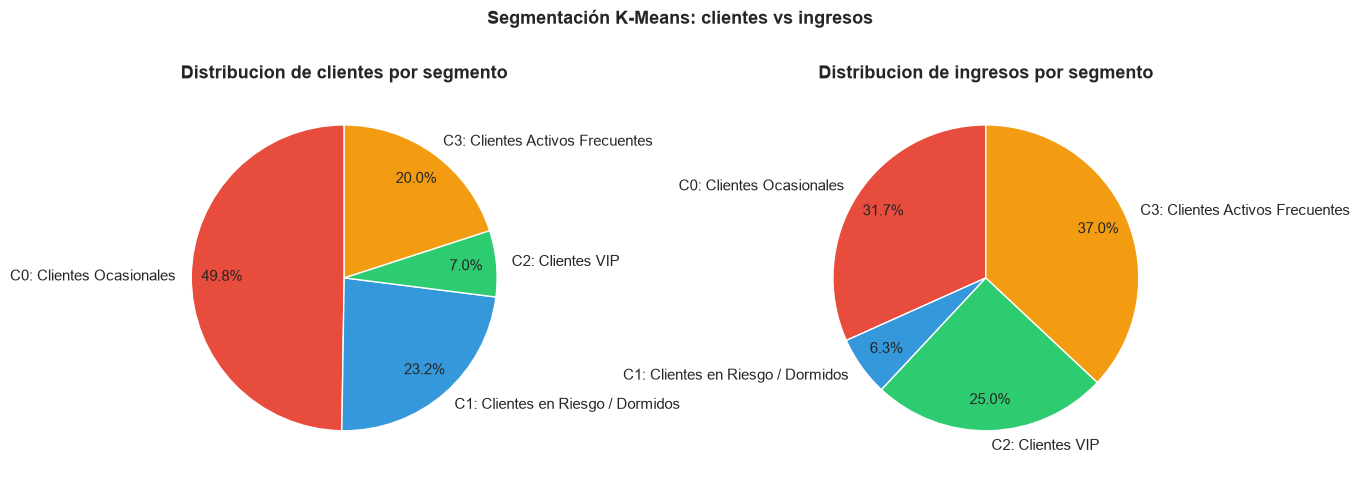

In [27]:
# Gráfico de torta: distribución de clientes e ingresos por segmento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

labels_pie = [f"C{int(r.Cluster)}: {r.Perfil}" for _, r in resumen_clusters.iterrows()]

ax1.pie(resumen_clusters['Clientes'], labels=labels_pie, autopct='%1.1f%%',
        colors=palette[:len(resumen_clusters)], startangle=90, pctdistance=0.8)
ax1.set_title('Distribucion de clientes por segmento', fontweight='bold')

ax2.pie(resumen_clusters['M_total'], labels=labels_pie, autopct='%1.1f%%',
        colors=palette[:len(resumen_clusters)], startangle=90, pctdistance=0.8)
ax2.set_title('Distribucion de ingresos por segmento', fontweight='bold')

plt.suptitle('Segmentación K-Means: clientes vs ingresos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_torta_segmentos.png', dpi=120, bbox_inches='tight')
plt.show()


### 4.2 Top reglas de asociación más relevantes


In [28]:
# Top 10 reglas por lift con interpretación
print("=== TOP 10 REGLAS DE ASOCIACIÓN (por Lift) ===\n")
top_reglas = reglas.head(10)

for i, (_, row) in enumerate(top_reglas.iterrows(), 1):
    ant = ', '.join(sorted(list(row['antecedents'])))
    con = ', '.join(sorted(list(row['consequents'])))
    print(f"{i:2}. SI se compra: [{ant}]")
    print(f"    ENTONCES también se compra: [{con}]")
    print(f"    Soporte:   {row['support']*100:.1f}%")
    print(f"    Confianza: {row['confidence']*100:.1f}%")
    print(f"    Lift:      {row['lift']:.2f}x")
    print()


=== TOP 10 REGLAS DE ASOCIACIÓN (por Lift) ===

 1. SI se compra: [Tarjeta Saludo]
    ENTONCES también se compra: [Bolsa Regalo Pequeña, Papel Tissue Colores]
    Soporte:   2.9%
    Confianza: 35.7%
    Lift:      11.86x

 2. SI se compra: [Bolsa Regalo Pequeña, Papel Tissue Colores]
    ENTONCES también se compra: [Tarjeta Saludo]
    Soporte:   2.9%
    Confianza: 95.2%
    Lift:      11.86x

 3. SI se compra: [Papel Tissue Colores, Tarjeta Saludo]
    ENTONCES también se compra: [Bolsa Regalo Pequeña]
    Soporte:   2.9%
    Confianza: 85.1%
    Lift:      10.65x

 4. SI se compra: [Bolsa Regalo Pequeña]
    ENTONCES también se compra: [Papel Tissue Colores, Tarjeta Saludo]
    Soporte:   2.9%
    Confianza: 35.9%
    Lift:      10.65x

 5. SI se compra: [Bolsa Regalo Grande, Cesta Desayuno]
    ENTONCES también se compra: [Lazo Decorativo]
    Soporte:   3.2%
    Confianza: 94.7%
    Lift:      8.31x

 6. SI se compra: [Lazo Decorativo]
    ENTONCES también se compra: [Bolsa Rega

---
## RECOMENDACIONES DE NEGOCIO

A partir del análisis de segmentación con K-Means y las reglas de asociación APRIORI, se proponen las siguientes acciones concretas:

### 🎯 Recomendación 1 — Programa de fidelización diferenciado por segmento

Los segmentos identificados con K-Means presentan comportamientos muy distintos. Se recomienda:

- **Clientes VIP y Activos Frecuentes**: ofrecer un programa de puntos y descuentos exclusivos. Son los que generan la mayor parte del ingreso; retenerlos es prioritario.
- **Clientes Ocasionales**: enviar campañas de email con ofertas limitadas en el tiempo (urgencia) para aumentar su frecuencia de compra.
- **Clientes en Riesgo / Dormidos**: activar campañas de reactivación con un cupón de descuento del 10-15% con mensaje personalizado "¡Te extrañamos!". Identificarlos antes de que se den de baja definitivamente.

### 🛒 Recomendación 2 — Bundles y cross-selling basados en reglas APRIORI

Las reglas de asociación revelaron combinaciones frecuentes de productos. Se sugiere:

- **Crear kits de producto** (bundles) con los pares de mayor Lift: por ejemplo, Portavelas + Vela Aromática o Difusor de Caña + Esencia. Ofrecerlos a un precio ligeramente menor que la compra individual.
- **Diseñar promociones "lleva el complemento"**: cuando un cliente agrega al carrito el producto antecedente, mostrar automáticamente el consecuente con un pequeño descuento.
- **Reorganizar la tienda física o virtual**: ubicar productos con alto Lift de forma contigua para favorecer la compra por impulso.

---
## CONCLUSIONES

Este proyecto aplicó exitosamente la metodología CRISP-DM sobre un dataset de transacciones de una tienda de artículos del hogar.

**K-Means** aplicado sobre variables de comportamiento de compra permitió segmentar los 400 clientes en 4 grupos claramente diferenciados, con un Silhouette Score que valida la calidad de la segmentación. Cada segmento tiene un perfil de comportamiento distinto que permite estrategias de marketing personalizadas.

**APRIORI** descubrió patrones de co-compra entre productos, especialmente en las categorías de velas, aromatización y regalería. Estas reglas, con Lift significativamente mayor a 1, confirman asociaciones reales (no aleatorias) que la tienda puede aprovechar en su estrategia de ventas.

La combinación de ambas técnicas proporciona una visión completa del comportamiento del cliente: **cómo se comportan** (K-Means) y **qué compran juntos** (APRIORI).


---
## Referencias

- Agrawal, R., & Srikant, R. (1994). *Fast algorithms for mining association rules*. VLDB.
- MacQueen, J. (1967). *Some methods for classification and analysis of multivariate observations*. 5th Berkeley Symposium.
- Hughes, A. M. (1994). *Strategic Database Marketing*. Chicago: Probus Publishing.
- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR 12.
- Rasanen, R. (2020). *mlxtend: Providing machine learning extensions*. v0.18.0.
- Chapman, P. et al. (2000). *CRISP-DM 1.0 Step-by-step data mining guide*. SPSS Inc.
